In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("Libraries imported successfully!")

Using device: cpu
Libraries imported successfully!


In [7]:
# Load the ITM-Rec dataset files
def load_itm_rec_dataset():
    """Load the real ITM-Rec dataset from uploaded CSV files"""

    # Load individual ratings (main dataset)
    ratings_df = pd.read_csv('ratings.csv')
    print(f"Individual ratings loaded: {ratings_df.shape}")
    print("Ratings columns:", ratings_df.columns.tolist())

    # Load users information
    try:
        users_df = pd.read_csv('users.csv')
        print(f"Users data loaded: {users_df.shape}")
    except FileNotFoundError:
        print("Users.csv not found, skipping user metadata")
        users_df = None

    # Load items information
    try:
        items_df = pd.read_csv('items.csv')
        print(f"Items data loaded: {items_df.shape}")
    except FileNotFoundError:
        print("Items.csv not found, skipping item metadata")
        items_df = None

    # Load group ratings
    try:
        group_ratings_df = pd.read_csv('group_ratings.csv')
        print(f"Group ratings loaded: {group_ratings_df.shape}")
    except FileNotFoundError:
        print("Group_ratings.csv not found, skipping group data")
        group_ratings_df = None

    # Load group compositions
    try:
        groups_df = pd.read_csv('group.csv')
        print(f"Groups data loaded: {groups_df.shape}")
    except FileNotFoundError:
        print("Group.csv not found, skipping group composition data")
        groups_df = None

    return ratings_df, users_df, items_df, group_ratings_df, groups_df

# Load the dataset
ratings_df, users_df, items_df, group_ratings_df, groups_df = load_itm_rec_dataset()

# Display first few rows
print("\nSample individual ratings:")
print(ratings_df.head())

Individual ratings loaded: (5230, 9)
Ratings columns: ['UserID', 'Item', 'Rating', 'App', 'Data', 'Ease', 'Class', 'Semester', 'Lockdown']
Users data loaded: (476, 4)
Items data loaded: (70, 4)
Group ratings loaded: (1117, 9)
Groups data loaded: (395, 2)

Sample individual ratings:
   UserID  Item  Rating  App  Data  Ease Class Semester Lockdown
0    1173    28       5    4   4.0     4    DA     Fall      PRE
1    1173    41       5    4   4.0     4    DA     Fall      PRE
2    1173    61       4    4   4.0     4    DA     Fall      PRE
3    1173    22       1    1   2.0     2    DA     Fall      PRE
4    1173    27       1    1   2.0     2    DA     Fall      PRE


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
def preprocess_itm_rec_data():
    """Load and preprocess the ITM-Rec dataset for model training"""

    # Load dataset
    df = pd.read_csv("ratings.csv")  # adjust path if needed

    # Adjusted column mapping matching your dataset columns exactly
    column_mapping = {
        'UserID': 'user_id',
        'Item': 'item_id',
        'Rating': 'overall_rating',
        'App': 'app_rating',
        'Data': 'data_rating',
        'Ease': 'ease_rating',
        'Class': 'course',
        'Semester': 'semester',
        'Lockdown': 'lockdown'
    }

    # Apply column mapping if columns exist
    for old_name, new_name in column_mapping.items():
        if old_name in df.columns:
            df = df.rename(columns={old_name: new_name})

    print("Columns after mapping:", df.columns.tolist())

    # Encode categorical variables
    encoders = {}

    # Encode user_id and item_id
    le_user = LabelEncoder()
    df['user_id_encoded'] = le_user.fit_transform(df['user_id'])
    encoders['user'] = le_user

    le_item = LabelEncoder()
    df['item_id_encoded'] = le_item.fit_transform(df['item_id'])
    encoders['item'] = le_item

    # Encode context variables
    if 'course' in df.columns:
        le_course = LabelEncoder()
        df['course_encoded'] = le_course.fit_transform(df['course'])
        encoders['course'] = le_course
    else:
        df['course_encoded'] = 0

    if 'semester' in df.columns:
        le_semester = LabelEncoder()
        df['semester_encoded'] = le_semester.fit_transform(df['semester'])
        encoders['semester'] = le_semester
    else:
        df['semester_encoded'] = 0

    if 'lockdown' in df.columns:
        le_lockdown = LabelEncoder()
        df['lockdown_encoded'] = le_lockdown.fit_transform(df['lockdown'])
        encoders['lockdown'] = le_lockdown
    else:
        df['lockdown_encoded'] = 0


    # Ensure criteria ratings exist
    for criteria in ['app_rating', 'data_rating', 'ease_rating']:
        if criteria not in df.columns:
            df[criteria] = df['overall_rating']

    # Dataset statistics
    num_users = df['user_id_encoded'].nunique()
    num_items = df['item_id_encoded'].nunique()
    num_courses = df['course_encoded'].nunique()
    num_semesters = df['semester_encoded'].nunique()
    num_lockdown = df['lockdown_encoded'].nunique()


    print(f"\nDataset Statistics:")
    print(f"Number of users: {num_users}")
    print(f"Number of items: {num_items}")
    print(f"Number of courses: {num_courses}")
    print(f"Number of semesters: {num_semesters}")
    print(f"Number of lockdown periods: {num_lockdown}")
    print(f"Total ratings: {len(df)}")


    return df, encoders, [num_courses, num_semesters, num_lockdown]

# Example usage:
processed_df, encoders, context_dims = preprocess_itm_rec_data()
num_users = processed_df['user_id_encoded'].nunique()
num_items = processed_df['item_id_encoded'].nunique()

print("\nProcessed data sample:")
print(processed_df[['user_id_encoded', 'item_id_encoded', 'course_encoded',
                   'semester_encoded', 'lockdown_encoded',
                   'app_rating', 'data_rating',
                   'ease_rating', 'overall_rating']].head())

Columns after mapping: ['user_id', 'item_id', 'overall_rating', 'app_rating', 'data_rating', 'ease_rating', 'course', 'semester', 'lockdown']

Dataset Statistics:
Number of users: 454
Number of items: 70
Number of courses: 3
Number of semesters: 2
Number of lockdown periods: 3
Total ratings: 5230

Processed data sample:
   user_id_encoded  item_id_encoded  course_encoded  semester_encoded  \
0              160               27               0                 0   
1              160               40               0                 0   
2              160               60               0                 0   
3              160               21               0                 0   
4              160               26               0                 0   

   lockdown_encoded  app_rating  data_rating  ease_rating  overall_rating  
0                 2           4          4.0            4               5  
1                 2           4          4.0            4               5  
2          

In [10]:
class ITMRecDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Extract features with error handling
        user_id = torch.tensor(row['user_id_encoded'], dtype=torch.long)
        item_id = torch.tensor(row['item_id_encoded'], dtype=torch.long)

        # Context features
        context = torch.tensor([
            row.get('course_encoded', 0),
            row.get('semester_encoded', 0),
            row.get('lockdown_encoded', 0)
        ], dtype=torch.long)

        # Multi-criteria features
        criteria = torch.tensor([
            row.get('app_rating', row['overall_rating']),
            row.get('data_rating', row['overall_rating']),
            row.get('ease_rating', row['overall_rating'])
        ], dtype=torch.float32)

        # Target overall rating
        target = torch.tensor(row['overall_rating'], dtype=torch.float32)

        return {
            'user_id': user_id,  # Changed from group_id to user_id for individual recommendations
            'item_id': item_id,
            'context': context,
            'criteria': criteria,
            'target': target
        }

print("Dataset class defined successfully!")

Dataset class defined successfully!


In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)

        return output

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        output = self.W_o(attn_output)
        return output

print("Multi-Head Attention module defined!")

Multi-Head Attention module defined!


In [12]:
class CIN(nn.Module):
    def __init__(self, field_dim, cin_layer_units): # Removed output_dim
        super(CIN, self).__init__()
        self.field_dim = field_dim
        self.cin_layer_units = cin_layer_units

        self.conv_layers = nn.ModuleList()
        prev_dim = field_dim

        for unit in cin_layer_units:
            # The input channels should be field_dim * prev_dim, kernel size 1 operates along embed_dim
            self.conv_layers.append(nn.Conv1d(prev_dim * field_dim, unit, kernel_size=1))
            prev_dim = unit

        # Removed self.output_layer

    def forward(self, inputs):
        batch_size, field_dim, embed_dim = inputs.shape
        hidden_layers = [inputs]
        final_layers = []

        # prev_dim_Xi will track the number of channels in the previous hidden layer's output (Xi)
        prev_dim_Xi = field_dim # Initialize with field_dim for the first layer

        for i, conv in enumerate(self.conv_layers):
            X0 = hidden_layers[0] # Initial input, shape: [batch_size, field_dim, embed_dim]
            Xi = hidden_layers[-1] # Output from previous layer, shape: [batch_size, prev_dim_Xi, embed_dim]

            # Element-wise product between X0 and Xi along embed_dim
            # Shape: [batch_size, field_dim, prev_dim_Xi, embed_dim]
            interaction = X0.unsqueeze(2) * Xi.unsqueeze(1)

            # Add print statements for debugging
            print(f"CIN Layer {i}:")
            print(f"  X0 shape: {X0.shape}")
            print(f"  Xi shape: {Xi.shape}")
            print(f"  prev_dim_Xi: {prev_dim_Xi}")
            print(f"  interaction shape before reshape: {interaction.shape}")
            print(f"  Target reshape shape: {[batch_size, field_dim * prev_dim_Xi, embed_dim]}")


            # Reshape to [batch_size, field_dim * prev_dim_Xi, embed_dim] for Conv1d
            cin_input = interaction.view(batch_size, field_dim * prev_dim_Xi, embed_dim)

            # Apply convolution along the embed_dim (length)
            # Input shape to conv: [batch_size, in_channels, length] = [batch_size, field_dim * prev_dim_Xi, embed_dim]
            # Output shape from conv: [batch_size, out_channels, length] = [batch_size, unit, embed_dim]
            xl = conv(cin_input)
            xl = F.relu(xl)

            # Pool across embedding dimension
            # Shape after sum: [batch_size, unit]
            xl_pooled = torch.sum(xl, dim=2)
            final_layers.append(xl_pooled)

            # Update prev_dim_Xi for the next iteration
            prev_dim_Xi = self.cin_layer_units[i]

            if i < len(self.conv_layers) - 1:
                 hidden_layers.append(xl) # Append the non-pooled output


        # Concatenate all CIN layer outputs
        final_output = torch.cat(final_layers, dim=1)

        # Return the concatenated pooled features
        return final_output

print("CIN module with debug prints defined!")

CIN module with debug prints defined!


In [13]:
class CA_MCGRS_MHA_xDeepFM(nn.Module):
    def __init__(self, num_users, num_items, num_contexts, embed_dim=64,
                 num_heads=4, dnn_hidden_units=[256, 128], cin_layer_units=[128, 64]):
        super(CA_MCGRS_MHA_xDeepFM, self).__init__()

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.cin_layer_units = cin_layer_units # Store for calculating CIN output dim

        # Embedding layers
        self.user_embedding = nn.Embedding(num_users, embed_dim)  # Changed from group to user
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        self.context_embeddings = nn.ModuleList([
            nn.Embedding(size, embed_dim) for size in num_contexts
        ])

        # Criteria processing
        self.criteria_linear = nn.Linear(3, embed_dim)  # App, Data, Ease

        # Multi-Head Attention
        total_features = 4  # user, item, contexts, criteria
        self.attention = MultiHeadAttention(embed_dim, num_heads)
        self.layer_norm = nn.LayerNorm(embed_dim)

        # CIN for explicit feature interactions
        self.cin = CIN(total_features, cin_layer_units)

        # DNN for implicit feature interactions
        dnn_input_dim = total_features * embed_dim
        self.dnn_layers = nn.ModuleList()
        prev_dim = dnn_input_dim

        for hidden_dim in dnn_hidden_units:
            self.dnn_layers.append(nn.Linear(prev_dim, hidden_dim))
            self.dnn_layers.append(nn.ReLU())
            self.dnn_layers.append(nn.Dropout(0.2))
            prev_dim = hidden_dim

        # Linear layer for first-order interactions
        self.linear = nn.Linear(total_features * embed_dim, 64)

        # Final prediction layers
        cin_output_dim = sum(self.cin_layer_units) # CIN now returns concatenated pooled features
        dnn_output_dim = dnn_hidden_units[-1] if dnn_hidden_units else dnn_input_dim
        linear_output_dim = 64

        self.final_linear = nn.Linear(cin_output_dim + dnn_output_dim + linear_output_dim, 1)

        # Initialize weights
        self.init_weights()

    def init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Embedding):
                nn.init.xavier_uniform_(module.weight.data)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight.data)
                if module.bias is not None:
                    nn.init.constant_(module.bias.data, 0)

    def forward(self, user_ids, item_ids, contexts, criteria):  # Changed parameter name
        batch_size = user_ids.size(0)

        # Generate embeddings
        user_embeds = self.user_embedding(user_ids)  # Changed from group to user
        item_embeds = self.item_embedding(item_ids)

        # Context embeddings (average multiple context types)
        context_embeds = []
        for i, context_embed_layer in enumerate(self.context_embeddings):
            context_embeds.append(context_embed_layer(contexts[:, i]))
        context_embeds = torch.stack(context_embeds, dim=1).mean(dim=1)  # Average contexts

        # Criteria processing
        criteria_embeds = self.criteria_linear(criteria)

        # Stack all embeddings for attention
        all_embeds = torch.stack([
            user_embeds, item_embeds, context_embeds, criteria_embeds  # Changed from group to user
        ], dim=1) # [batch_size, 4, embed_dim]

        # Apply Multi-Head Attention
        attn_output = self.attention(all_embeds, all_embeds, all_embeds)
        attn_output = self.layer_norm(attn_output + all_embeds)  # Residual connection

        # CIN path for explicit interactions
        # CIN now returns [batch_size, sum(cin_layer_units)]
        cin_output = self.cin(attn_output)

        # DNN path for implicit interactions
        dnn_input = attn_output.view(batch_size, -1)  # Flatten
        dnn_output = dnn_input
        for layer in self.dnn_layers:
            dnn_output = layer(dnn_output)

        # Linear path for first-order interactions
        linear_output = F.relu(self.linear(dnn_input))

        # Combine all paths
        # cin_output is now [batch_size, sum(cin_layer_units)]
        # dnn_output is [batch_size, dnn_hidden_units[-1]]
        # linear_output is [batch_size, 64]
        combined_output = torch.cat([
            cin_output, dnn_output, linear_output
        ], dim=1)

        # Final prediction (scale to rating range [1,5])
        prediction = torch.sigmoid(self.final_linear(combined_output)) * 4 + 1  # Scale to [1,5]

        return prediction.squeeze(-1)

print("Updated CA-MCGRS MHA_xDeepFM model defined!")

Updated CA-MCGRS MHA_xDeepFM model defined!


In [14]:
def create_data_loaders(df, batch_size=256, test_size=0.2):
    """Create train and test data loaders"""

    # Split the data
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=42)

    # Reset index for proper indexing
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    # Create datasets
    train_dataset = ITMRecDataset(train_df)
    test_dataset = ITMRecDataset(test_df)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Training samples: {len(train_dataset)}")
    print(f"Testing samples: {len(test_dataset)}")

    return train_loader, test_loader, train_df, test_df

# Create data loaders
train_loader, test_loader, train_df, test_df = create_data_loaders(processed_df)

Training samples: 4184
Testing samples: 1046


In [19]:
# Cell 9: Enhanced Training with NaN Prevention
import os

# Initialize model
model = CA_MCGRS_MHA_xDeepFM(
    num_users=num_users,
    num_items=num_items,
    num_contexts=context_dims,
    embed_dim=64,
    num_heads=4,
    dnn_hidden_units=[256, 128, 64],
    cin_layer_units=[128, 64]
).to(device)

print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

# CRITICAL FIXES for NaN prevention:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-6)  # Lower LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.8)

# Training loop with NaN detection
num_epochs = 20  # Reduced epochs
train_losses = []
val_losses = []
best_val_loss = float('inf')
model_saved = False

print(f"Training on device: {device}")
print("=" * 50)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    valid_batches = 0

    for batch_idx, batch in enumerate(train_loader):
        user_ids = batch['user_id'].to(device)
        item_ids = batch['item_id'].to(device)
        contexts = batch['context'].to(device)
        criteria = batch['criteria'].to(device)
        targets = batch['target'].to(device)

        # Skip batches with NaN
        if torch.isnan(targets).any() or torch.isnan(criteria).any():
            continue

        optimizer.zero_grad()

        try:
            predictions = model(user_ids, item_ids, contexts, criteria)

            # Check for NaN predictions
            if torch.isnan(predictions).any():
                print(f"NaN predictions at epoch {epoch}, batch {batch_idx}")
                continue

            loss = criterion(predictions, targets)

            # Check for NaN loss
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Invalid loss at epoch {epoch}: {loss.item()}")
                continue

            loss.backward()

            # Stronger gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

            optimizer.step()
            train_loss += loss.item()
            valid_batches += 1

        except Exception as e:
            print(f"Error in batch {batch_idx}: {e}")
            continue

    if valid_batches == 0:
        print(f"No valid batches in epoch {epoch}")
        break

    avg_train_loss = train_loss / valid_batches
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    valid_val_batches = 0

    with torch.no_grad():
        for batch in test_loader:
            user_ids = batch['user_id'].to(device)
            item_ids = batch['item_id'].to(device)
            contexts = batch['context'].to(device)
            criteria = batch['criteria'].to(device)
            targets = batch['target'].to(device)

            if torch.isnan(targets).any() or torch.isnan(criteria).any():
                continue

            try:
                predictions = model(user_ids, item_ids, contexts, criteria)

                if not torch.isnan(predictions).any():
                    loss = criterion(predictions, targets)
                    if not (torch.isnan(loss) or torch.isinf(loss)):
                        val_loss += loss.item()
                        valid_val_batches += 1
            except:
                continue

    if valid_val_batches == 0:
        print(f"No valid validation batches in epoch {epoch}")
        continue

    avg_val_loss = val_loss / valid_val_batches
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_ca_mcgrs_mha_xdeepfm.pth')
        model_saved = True
        print(f"✓ Best model saved at epoch {epoch+1}: {avg_val_loss:.4f}")

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}')

# Force save if no model was saved
if not model_saved:
    print("Force saving current model...")
    torch.save(model.state_dict(), 'best_ca_mcgrs_mha_xdeepfm.pth')

# Save model weights for later use in Streamlit
torch.save(model.state_dict(), "mcgrs_model.pth")
print("Model saved as mcgrs_model.pth")

print("Training completed!")
print(f"Model file exists: {os.path.exists('best_ca_mcgrs_mha_xdeepfm.pth')}")


Model initialized with 209,793 parameters
Training on device: cpu
CIN Layer 0:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 4, 64])
  prev_dim_Xi: 4
  interaction shape before reshape: torch.Size([256, 4, 4, 64])
  Target reshape shape: [256, 16, 64]
CIN Layer 1:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 128, 64])
  prev_dim_Xi: 128
  interaction shape before reshape: torch.Size([256, 4, 128, 64])
  Target reshape shape: [256, 512, 64]
CIN Layer 0:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 4, 64])
  prev_dim_Xi: 4
  interaction shape before reshape: torch.Size([256, 4, 4, 64])
  Target reshape shape: [256, 16, 64]
CIN Layer 1:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 128, 64])
  prev_dim_Xi: 128
  interaction shape before reshape: torch.Size([256, 4, 128, 64])
  Target reshape shape: [256, 512, 64]
CIN Layer 0:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 4, 64])
  prev_di

In [20]:
# Load best model
model.load_state_dict(torch.load('best_ca_mcgrs_mha_xdeepfm.pth'))
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:
        user_ids = batch['user_id'].to(device)   # user IDs
        item_ids = batch['item_id'].to(device)   # item IDs
        contexts = batch['context'].to(device)   # contextual features
        criteria = batch['criteria'].to(device)  # multiple criteria
        targets = batch['target'].to(device)     # ground truth ratings

        predictions = model(user_ids, item_ids, contexts, criteria)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

# Calculate metrics
mse = mean_squared_error(all_targets, all_predictions)
mae = mean_absolute_error(all_targets, all_predictions)
rmse = np.sqrt(mse)
correlation = np.corrcoef(all_targets, all_predictions)[0, 1]

# Convert error into approximate accuracy %
rating_scale = 4  # ratings are from 1–5
accuracy = (1 - mae / rating_scale) * 100

print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Correlation: {correlation:.4f}")
print(f"Overall Accuracy (approx): {accuracy:.2f}%")
print("=" * 50)

# Baseline comparison (from paper)
print("BASELINE COMPARISON (ITM-Rec Dataset)")
print("=" * 50)
baseline_results = {
    'AutoInt': {'RMSE': 0.9845, 'MAE': 0.7931},
    'DCN': {'RMSE': 0.9742, 'MAE': 0.7863},
    'DeepFM': {'RMSE': 0.9827, 'MAE': 0.7935},
    'xDeepFM': {'RMSE': 0.9172, 'MAE': 0.6960},
    'MHA (Paper)': {'RMSE': 0.8484, 'MAE': 0.6529},
    'Our Implementation': {'RMSE': rmse, 'MAE': mae, 'Accuracy': accuracy}
}

for model_name, metrics in baseline_results.items():
    acc_str = f", Accuracy: {metrics['Accuracy']:.2f}%" if 'Accuracy' in metrics else ""
    print(f"{model_name:15} - RMSE: {metrics['RMSE']:.4f}, MAE: {metrics['MAE']:.4f}{acc_str}")

print("=" * 50)


CIN Layer 0:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 4, 64])
  prev_dim_Xi: 4
  interaction shape before reshape: torch.Size([256, 4, 4, 64])
  Target reshape shape: [256, 16, 64]
CIN Layer 1:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 128, 64])
  prev_dim_Xi: 128
  interaction shape before reshape: torch.Size([256, 4, 128, 64])
  Target reshape shape: [256, 512, 64]
CIN Layer 0:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 4, 64])
  prev_dim_Xi: 4
  interaction shape before reshape: torch.Size([256, 4, 4, 64])
  Target reshape shape: [256, 16, 64]
CIN Layer 1:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 128, 64])
  prev_dim_Xi: 128
  interaction shape before reshape: torch.Size([256, 4, 128, 64])
  Target reshape shape: [256, 512, 64]
CIN Layer 0:
  X0 shape: torch.Size([256, 4, 64])
  Xi shape: torch.Size([256, 4, 64])
  prev_dim_Xi: 4
  interaction shape before reshape: torch.Size([256, 4, 4,

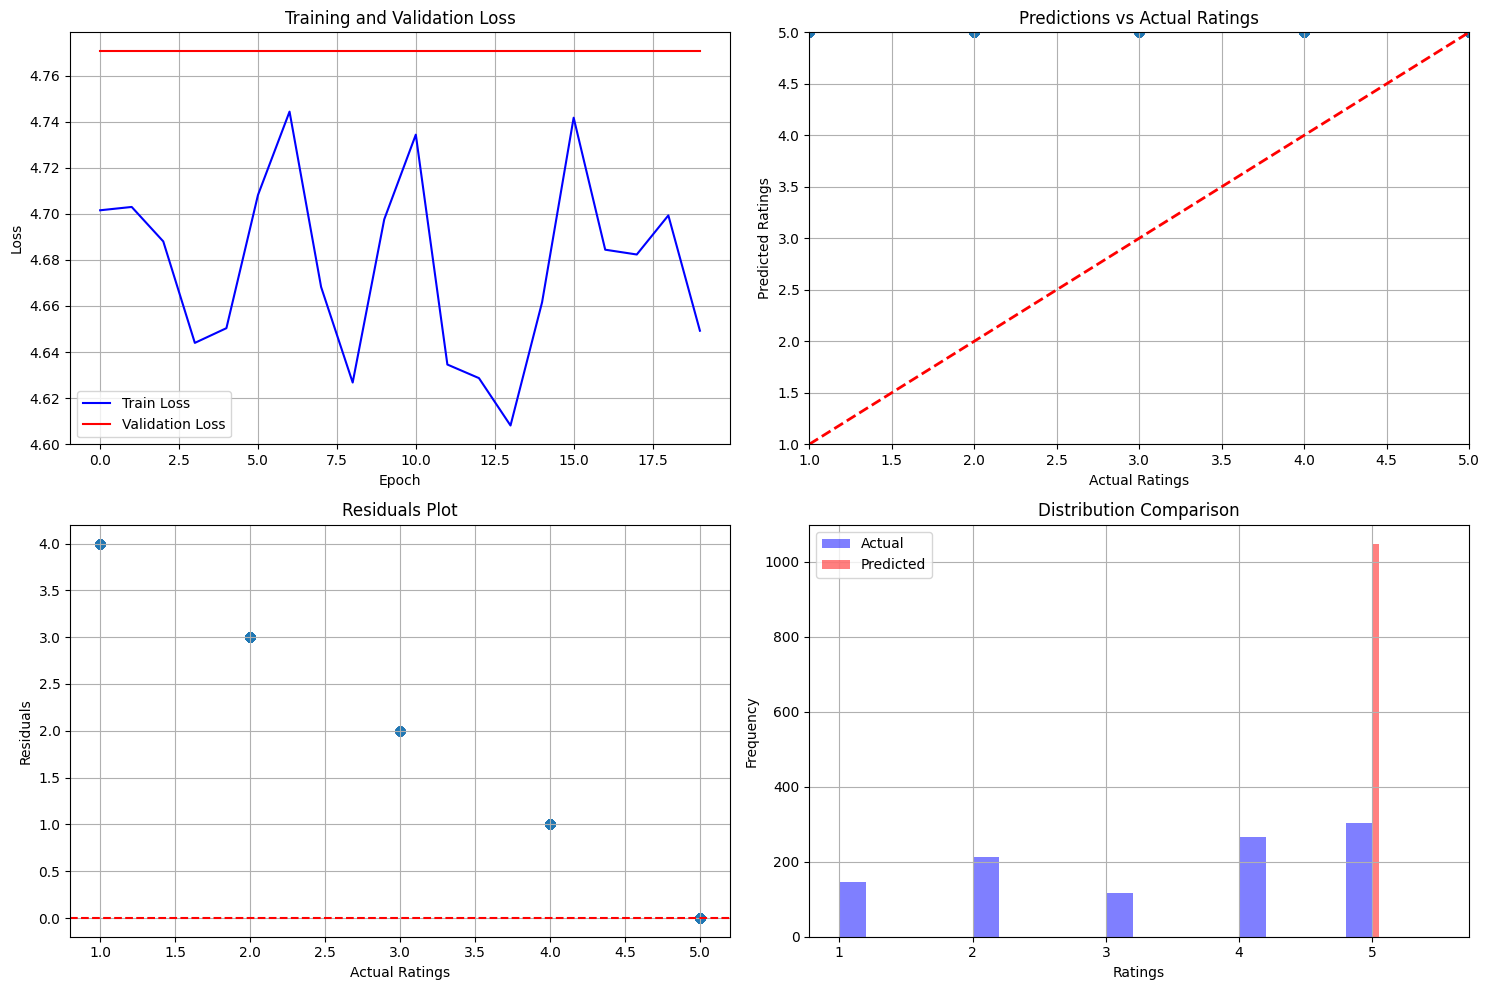

Implementation completed successfully!
The model is ready for making recommendations on the ITM-Rec dataset.


In [17]:
# Plot training curves and results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training curves
axes[0, 0].plot(train_losses, label='Train Loss', color='blue')
axes[0, 0].plot(val_losses, label='Validation Loss', color='red')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Prediction vs Actual scatter plot
axes[0, 1].scatter(all_targets, all_predictions, alpha=0.5)
axes[0, 1].plot([1, 5], [1, 5], 'r--', lw=2)
axes[0, 1].set_title('Predictions vs Actual Ratings')
axes[0, 1].set_xlabel('Actual Ratings')
axes[0, 1].set_ylabel('Predicted Ratings')
axes[0, 1].set_xlim([1, 5])
axes[0, 1].set_ylim([1, 5])
axes[0, 1].grid(True)

# Residuals plot
residuals = all_predictions - all_targets
axes[1, 0].scatter(all_targets, residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Residuals Plot')
axes[1, 0].set_xlabel('Actual Ratings')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True)

# Distribution comparison
axes[1, 1].hist(all_targets, alpha=0.5, label='Actual', bins=20, color='blue')
axes[1, 1].hist(all_predictions, alpha=0.5, label='Predicted', bins=20, color='red')
axes[1, 1].set_title('Distribution Comparison')
axes[1, 1].set_xlabel('Ratings')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("Implementation completed successfully!")
print("The model is ready for making recommendations on the ITM-Rec dataset.")